In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms.functional as TF

In [5]:
import cv2
from sklearn.metrics import roc_auc_score

In [6]:
#for reproducibility in the entire code base
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [7]:
#defining paths
DATASET_PATH = "/content/drive/MyDrive/balanced_dataset"
MODEL_SAVE_PATH = "/content/drive/MyDrive/best_seg_model.pth"
CLASSIFIER_PATH = "/content/drive/MyDrive/best_model1.pth"

In [8]:
#setting up the hyper-parameters
IMG_SIZE     = 224       # same as classifier — keeping preprocessing consistent
BATCH_SIZE   = 8         # T4 has 15 GB VRAM; U-Net with skip connections uses
                         # ~2× more memory than a classifier — 8 is safe
LR           = 1e-4      # same Adam learning rate as Stage 1
NUM_EPOCHS   = 10        # segmentation needs more epochs than classification
DICE_WEIGHT  = 0.5       # weight for Dice loss in combined loss
BCE_WEIGHT   = 0.5       # weight for BCE loss in combined loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [9]:
class FetalSegmentationDataset(Dataset):
    """
    Loads positive-class ultrasound slices with their segmentation masks.

    Positive slices are the only ones with meaningful (non-empty) masks,
    so training on negatives (all-black masks) would teach the model nothing
    about anatomy and hurt convergence.

    Args:
        csv_file  : path to labels.csv for this split
        image_dir : path to the images/ folder for this split
        mask_dir  : path to the masks/ folder for this split
        augment   : whether to apply random augmentation (True for train only)
    """

    def __init__(self, csv_file, image_dir, mask_dir, augment=False):
        df = pd.read_csv(csv_file)

        # Keep only positive slices — segmentation is only meaningful here
        self.data = df[df['class'] == 1].reset_index(drop=True)

        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.augment   = augment

        # Normalization stats computed from the training split in Stage 1
        # We use the same values for consistency across the whole project
        self.mean = 0.11916620971431377
        self.std  = 0.1479186227862317

        print(f"  Loaded {len(self.data)} positive slices from {csv_file}")

    def __len__(self):
        return len(self.data)

    def _pad_to_square(self, img):
        """
        Zero-pad the shorter side so the image becomes square.
        This preserves the aspect ratio of anatomical structures —
        critical for the elliptical abdominal contour.
        Same logic as PadToSquare in Stage 1, applied to PIL images.
        """
        w, h = img.size
        max_side = max(w, h)

        pad_left   = (max_side - w) // 2
        pad_right  = max_side - w - pad_left
        pad_top    = (max_side - h) // 2
        pad_bottom = max_side - h - pad_top

        return TF.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=0)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # --- Load image as grayscale ---
        img  = Image.open(os.path.join(self.image_dir, row['image_name'])).convert("L")

        # --- Load mask ---
        # Mask pixels are already 0 or 1 (confirmed).
        # We open as "L" (8-bit grayscale) because PIL stores 0/1 as 0/1 in L mode.
        mask = Image.open(os.path.join(self.mask_dir, row['mask_name'])).convert("L")

        # --- Ground-truth AC value (in mm) — used for evaluation only ---
        # Column name may vary; adjust 'ac' below if yours differs
        ac_value = float(row['circumference']) if 'circumference' in row.index else None

        # --- Shared geometric transforms ---
        # IMPORTANT: image and mask receive IDENTICAL random transforms.
        # We achieve this by generating the random parameters once and
        # applying them manually with torchvision.transforms.functional.

        img  = self._pad_to_square(img)
        mask = self._pad_to_square(mask)

        img  = TF.resize(img,  [IMG_SIZE, IMG_SIZE])
        mask = TF.resize(mask, [IMG_SIZE, IMG_SIZE],
                         interpolation=TF.InterpolationMode.NEAREST)
        # NEAREST interpolation for the mask is essential — bilinear would
        # introduce intermediate values (e.g. 0.4, 0.6) in a binary mask

        if self.augment:
            # Random horizontal flip — same decision for image and mask
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)

            # Random rotation — same angle for image and mask
            angle = random.uniform(-10, 10)
            img  = TF.rotate(img,  angle)
            mask = TF.rotate(mask, angle)

        # --- Convert to tensors ---
        img  = TF.to_tensor(img)   # shape: [1, H, W], values in [0, 1]
        mask = TF.to_tensor(mask)  # shape: [1, H, W], values 0.0 or 1.0

        # --- Replicate grayscale to 3 channels for pretrained ResNet encoder ---
        img = img.repeat(3, 1, 1)  # shape: [3, H, W]

        # --- Normalize image with domain-specific stats ---
        img = TF.normalize(img,
                           mean=[self.mean] * 3,
                           std=[self.std]  * 3)

        # Mask stays binary — no normalization
        # Clamp to {0, 1} to be safe against any interpolation artifacts
        mask = (mask > 0).float()

        if ac_value is not None:
            return img, mask, torch.tensor(ac_value, dtype=torch.float32)
        else:
            return img, mask, torch.tensor(-1.0)  # sentinel if AC not available



In [10]:
# ---------------------------------------------------------------------------
# Build datasets and dataloaders
# ---------------------------------------------------------------------------

print("Loading datasets...")

train_dataset = FetalSegmentationDataset(
    csv_file  = f"{DATASET_PATH}/train/labels.csv",
    image_dir = f"{DATASET_PATH}/train/images",
    mask_dir  = f"{DATASET_PATH}/train/masks",
    augment   = True   # augmentation ON for training
)

val_dataset = FetalSegmentationDataset(
    csv_file  = f"{DATASET_PATH}/val/labels.csv",
    image_dir = f"{DATASET_PATH}/val/images",
    mask_dir  = f"{DATASET_PATH}/val/masks",
    augment   = False  # no augmentation for validation
)

test_dataset = FetalSegmentationDataset(
    csv_file  = f"{DATASET_PATH}/test/labels.csv",
    image_dir = f"{DATASET_PATH}/test/images",
    mask_dir  = f"{DATASET_PATH}/test/masks",
    augment   = False  # no augmentation for test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0,
pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
pin_memory=False)

# Quick sanity check
images, masks, ac_vals = next(iter(train_loader))
print(f"\nBatch shapes — image: {images.shape}, mask: {masks.shape}")
print(f"Mask unique values: {masks.unique()}")   # should be tensor([0., 1.])
print(f"AC values sample:   {ac_vals[:4]}")


Loading datasets...
  Loaded 4174 positive slices from /content/drive/MyDrive/balanced_dataset/train/labels.csv
  Loaded 567 positive slices from /content/drive/MyDrive/balanced_dataset/val/labels.csv
  Loaded 521 positive slices from /content/drive/MyDrive/balanced_dataset/test/labels.csv

Batch shapes — image: torch.Size([8, 3, 224, 224]), mask: torch.Size([8, 1, 224, 224])
Mask unique values: tensor([0., 1.])
AC values sample:   tensor([210.4665, 206.3654, 191.8643, 260.9149])


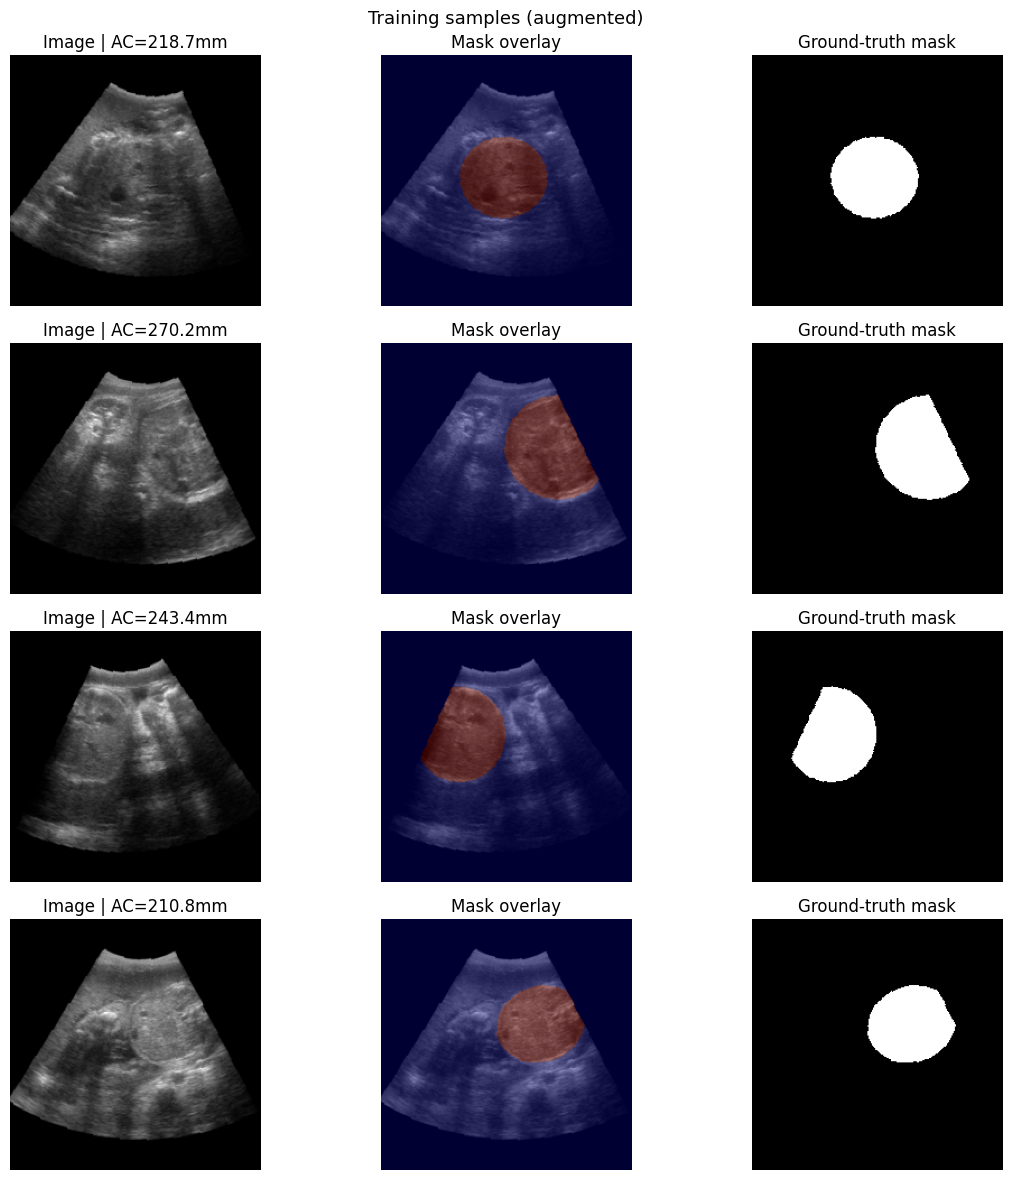

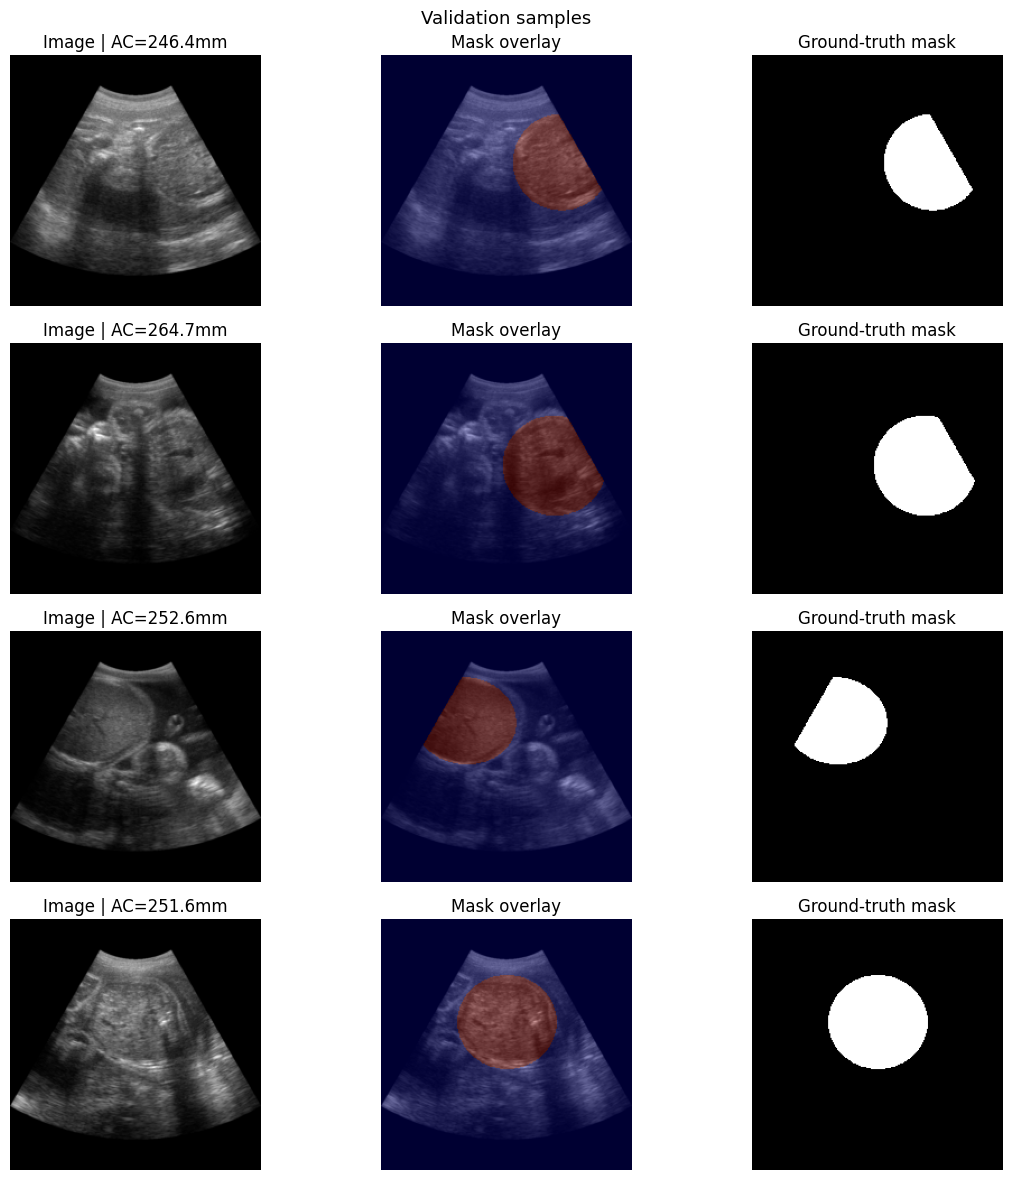

In [11]:
#dataset visualization
def visualize_segmentation_samples(dataset, n=4, title="Samples"):
    """
    Shows n samples side by side: original image | mask overlay | mask alone.
    Run this before training to confirm correct image-mask alignment.
    """
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3))
    indices = random.sample(range(len(dataset)), n)

    for row_idx, sample_idx in enumerate(indices):
        img, mask, ac = dataset[sample_idx]

        # Undo normalization for display
        # We replicated the grayscale channel, so all 3 channels are identical
        img_display = img[0].numpy()   # take first channel
        img_display = img_display * dataset.std + dataset.mean
        img_display = np.clip(img_display, 0, 1)

        mask_display = mask[0].numpy()

        # Column 1: original image
        axes[row_idx, 0].imshow(img_display, cmap='gray')
        axes[row_idx, 0].set_title(f"Image | AC={ac:.1f}mm" if ac > 0 else "Image")
        axes[row_idx, 0].axis('off')

        # Column 2: mask overlay on image
        axes[row_idx, 1].imshow(img_display, cmap='gray')
        axes[row_idx, 1].imshow(mask_display, cmap='jet', alpha=0.4)
        axes[row_idx, 1].set_title("Mask overlay")
        axes[row_idx, 1].axis('off')

        # Column 3: mask alone
        axes[row_idx, 2].imshow(mask_display, cmap='gray')
        axes[row_idx, 2].set_title("Ground-truth mask")
        axes[row_idx, 2].axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_segmentation_samples(train_dataset, n=4, title="Training samples (augmented)")
visualize_segmentation_samples(val_dataset,   n=4, title="Validation samples")



In [12]:
# SECTION 3 — U-NET ARCHITECTURE

# Architecture: U-Net with a pretrained ResNet-34 encoder.

# Purpose of reusing the ResNet-34 encoder
#   - The encoder already learned to recognize abdominal features during
#     Stage 1 classification training. Reusing those weights gives the
#     segmentation model a head start on ultrasound-specific representations.
#   - This is more sample-efficient than training a U-Net from scratch,
#     especially with only ~4,174 positive training slices.
#
# Structure:
#   Encoder (ResNet-34 layers 1–4) → Bottleneck → Decoder (4 upsampling blocks)
#   Each decoder block receives a skip connection from the corresponding encoder layer.
#
# Output:
#   A single-channel probability map of shape [B, 1, H, W].
#  Each value is the probability that pixel belongs to the fetal abdomen.

class DecoderBlock(nn.Module):
    """
    One upsampling step in the U-Net decoder.

    Takes the upsampled feature map from the previous decoder step and the
    skip connection from the matching encoder layer, concatenates them,
    then applies two conv-BN-ReLU operations to refine the combined features.

    Args:
        in_channels  : channels from the upsampled (previous decoder) feature map
        skip_channels: channels from the skip connection (encoder feature map)
        out_channels : output channels after this block
    """

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        # After concatenation: in_channels + skip_channels
        combined = in_channels + skip_channels

        self.block = nn.Sequential(
            # Conv 1
            nn.Conv2d(combined, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Conv 2 — second conv refines features at the same spatial resolution
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        # Upsample x to match the spatial dimensions of the skip connection
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        # Concatenate along the channel dimension
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


class UNetResNet34(nn.Module):
    """
    U-Net segmentation model with a ResNet-34 encoder backbone.

    The encoder extracts feature maps at 5 spatial scales.
    The decoder progressively upsamples back to the input resolution,
    combining features from each scale via skip connections.

    Input:  [B, 3, 224, 224]  (3-channel grayscale replicated, normalized)
    Output: [B, 1, 224, 224]  (per-pixel abdomen probability, raw logits)
                               Apply sigmoid before thresholding at inference.
    """

    def __init__(self, pretrained=True):
        super().__init__()

        # --- Encoder: ResNet-34 ---
        # We extract feature maps at 5 spatial scales by accessing
        # internal ResNet layers directly.
        backbone = models.resnet34(pretrained=pretrained)

        # Scale 0 — initial conv + BN + ReLU (before any pooling)
        # Output: [B, 64, 112, 112]
        self.enc0 = nn.Sequential(
            backbone.conv1,   # 7×7 conv, stride 2
            backbone.bn1,
            backbone.relu,
        )

        # Scale 1 — max pool + residual block layer 1
        # Output: [B, 64, 56, 56]
        self.enc1 = nn.Sequential(
            backbone.maxpool,
            backbone.layer1,
        )

        # Scale 2 — residual block layer 2, stride 2
        # Output: [B, 128, 28, 28]
        self.enc2 = backbone.layer2

        # Scale 3 — residual block layer 3, stride 2
        # Output: [B, 256, 14, 14]
        self.enc3 = backbone.layer3

        # Scale 4 (bottleneck) — residual block layer 4, stride 2
        # Output: [B, 512, 7, 7]
        self.enc4 = backbone.layer4

        # --- Decoder: 4 upsampling blocks ---
        # Each block doubles spatial resolution and halves channels.
        # Parameters: (in_channels_from_below, skip_channels, out_channels)

        self.dec4 = DecoderBlock(512, 256, 256)  # 7×7   → 14×14
        self.dec3 = DecoderBlock(256, 128, 128)  # 14×14 → 28×28
        self.dec2 = DecoderBlock(128,  64,  64)  # 28×28 → 56×56
        self.dec1 = DecoderBlock( 64,  64,  32)  # 56×56 → 112×112

        # Final upsample to match input resolution (112×112 → 224×224)
        # No skip connection at this stage — just upsample and refine
        self.final_upsample = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )

        # --- Output head ---
        # 1×1 conv produces a single-channel logit map
        # No sigmoid here — BCEWithLogitsLoss applies it internally (more stable)
        self.output_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        # --- Encoder forward pass ---
        e0 = self.enc0(x)   # [B, 64,  112, 112]
        e1 = self.enc1(e0)  # [B, 64,   56,  56]
        e2 = self.enc2(e1)  # [B, 128,  28,  28]
        e3 = self.enc3(e2)  # [B, 256,  14,  14]
        e4 = self.enc4(e3)  # [B, 512,   7,   7]  ← bottleneck

        # --- Decoder forward pass (with skip connections) ---
        d4 = self.dec4(e4, e3)  # [B, 256, 14,  14]
        d3 = self.dec3(d4, e2)  # [B, 128, 28,  28]
        d2 = self.dec2(d3, e1)  # [B, 64,  56,  56]
        d1 = self.dec1(d2, e0)  # [B, 32,  112, 112]

        # Upsample from 112×112 → 224×224 to match input resolution
        out = F.interpolate(d1, scale_factor=2, mode='bilinear', align_corners=False)
        out = self.final_upsample(out)  # [B, 16, 224, 224]

        # Output logits — shape: [B, 1, 224, 224]
        return self.output_conv(out)


In [13]:
# Instantiating the model and move to device

model = UNetResNet34(pretrained=True).to(device)

# Counting trainable parameters — useful to report in methodology
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters: {total_params:,} total | {trainable_params:,} trainable")

# Quick shape check — to confirm output matches input resolution
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    print(f"Input shape:  {dummy.shape}")
    print(f"Output shape: {out.shape}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 185MB/s]



Model parameters: 24,433,905 total | 24,433,905 trainable
Input shape:  torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 1, 224, 224])


In [14]:
# =============================================================================
# SECTION 4 — LOSS FUNCTION
# =============================================================================
# Combined Dice + BCE loss addresses pixel-level class imbalance.
#
# The problem: even in positive slices, the abdomen occupies only a fraction
# of pixels. A model predicting all zeros achieves high pixel accuracy but
# zero clinical value.
#
# BCE loss: penalizes each pixel independently — fast gradients, but blind
#           to the foreground/background imbalance.
# Dice loss: measures mask overlap directly — punishes empty predictions
#            regardless of how many background pixels were correct.
#
# Combined: stable training (BCE) + strong contour learning (Dice)
# =============================================================================

class DiceLoss(nn.Module):
    """
    Soft Dice loss for binary segmentation.

    Dice = 2 × |P ∩ G| / (|P| + |G|)
    Dice Loss = 1 − Dice

    Uses soft (differentiable) version during training:
    applies sigmoid to logits and uses continuous values, not hard thresholds.
    The smooth term (1e-6) prevents division by zero on empty masks.
    """

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Convert logits to probabilities
        probs = torch.sigmoid(logits)

        # Flatten spatial dimensions: [B, 1, H, W] → [B, H*W]
        probs   = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        # Compute per-sample Dice, then average over the batch
        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / \
               (probs.sum(dim=1) + targets.sum(dim=1) + self.smooth)

        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """
    Weighted sum of Dice loss and BCE loss.

    Default weights: 0.5 Dice + 0.5 BCE.
    Both terms are in [0, 1], so the combined loss is also in [0, 1].
    """

    def __init__(self, dice_weight=DICE_WEIGHT, bce_weight=BCE_WEIGHT):
        super().__init__()
        self.dice     = DiceLoss()
        self.bce      = nn.BCEWithLogitsLoss()
        self.dice_w   = dice_weight
        self.bce_w    = bce_weight

    def forward(self, logits, targets):
        loss_dice = self.dice(logits, targets)
        loss_bce  = self.bce(logits, targets)
        return self.dice_w * loss_dice + self.bce_w * loss_bce


criterion = CombinedLoss()

In [15]:

# SECTION 5 — OPTIMIZER AND LEARNING RATE STRATEGY

# We use two different learning rates:
#   - Encoder (pretrained ResNet-34 weights): small LR (1e-5)
#     These weights are already well-trained; large updates would destroy them.
#   - Decoder (randomly initialized): full LR (1e-4)
#     These weights start from scratch and need larger updates.
#
# This is called "differential learning rates" and is standard practice
# when fine-tuning pretrained encoders.


optimizer = optim.Adam([
    # Encoder parameters — 10× smaller learning rate
    {'params': model.enc0.parameters(), 'lr': LR * 0.1},
    {'params': model.enc1.parameters(), 'lr': LR * 0.1},
    {'params': model.enc2.parameters(), 'lr': LR * 0.1},
    {'params': model.enc3.parameters(), 'lr': LR * 0.1},
    {'params': model.enc4.parameters(), 'lr': LR * 0.1},
    # Decoder parameters — full learning rate
    {'params': model.dec4.parameters(), 'lr': LR},
    {'params': model.dec3.parameters(), 'lr': LR},
    {'params': model.dec2.parameters(), 'lr': LR},
    {'params': model.dec1.parameters(), 'lr': LR},
    {'params': model.final_upsample.parameters(), 'lr': LR},
    {'params': model.output_conv.parameters(),    'lr': LR},
], lr=LR)

# ReduceLROnPlateau: halve the learning rate if val Dice doesn't improve
# for 5 consecutive epochs. Prevents oscillating around a local minimum.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)


In [16]:
# SECTION 6 — METRIC FUNCTIONS
def dice_coefficient(pred_mask, true_mask, threshold=0.5, smooth=1e-6):
    """
    Compute the Dice coefficient between predicted and ground-truth masks.
    This is the evaluation metric (higher = better), not the training loss.

    Args:
        pred_mask : predicted probabilities, shape [B, 1, H, W]
        true_mask : ground-truth binary mask, shape [B, 1, H, W]
        threshold : probability cutoff to binarize predictions
        smooth    : prevents division by zero

    Returns:
        Mean Dice coefficient over the batch (scalar)
    """
    # Binarize predictions
    pred_binary = (pred_mask > threshold).float()

    pred_flat = pred_binary.view(pred_binary.size(0), -1)
    true_flat = true_mask.view(true_mask.size(0), -1)

    intersection = (pred_flat * true_flat).sum(dim=1)
    dice = (2.0 * intersection + smooth) / \
           (pred_flat.sum(dim=1) + true_flat.sum(dim=1) + smooth)

    return dice.mean().item()


def iou_score(pred_mask, true_mask, threshold=0.5, smooth=1e-6):
    """
    Compute Intersection over Union (IoU / Jaccard index).
    Stricter than Dice — penalizes false positives and negatives more.

    IoU = |P ∩ G| / |P ∪ G|
        = intersection / (pred_area + true_area - intersection)
    """
    pred_binary = (pred_mask > threshold).float()

    pred_flat = pred_binary.view(pred_binary.size(0), -1)
    true_flat = true_mask.view(true_mask.size(0), -1)

    intersection = (pred_flat * true_flat).sum(dim=1)
    union        = pred_flat.sum(dim=1) + true_flat.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

In [17]:
# SECTION 7 — TRAINING AND VALIDATION LOOPS

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Run one full pass over the training set.
    Returns the average combined loss for the epoch.
    """
    model.train()
    running_loss = 0.0

    for images, masks, _ in loader:       # _ = AC values, not needed during training
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)             # [B, 1, 224, 224] raw logits
        loss   = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    """
    Evaluate the model on a validation or test split.

    Returns:
        val_loss  : average combined loss
        mean_dice : average Dice coefficient (our primary model-selection metric)
        mean_iou  : average IoU score
    """
    model.eval()

    running_loss = 0.0
    all_dice     = []
    all_iou      = []

    with torch.no_grad():
        for images, masks, _ in loader:
            images = images.to(device)
            masks  = masks.to(device)

            logits = model(images)
            loss   = criterion(logits, masks)

            # Convert logits to probabilities for metric computation
            probs  = torch.sigmoid(logits)

            running_loss += loss.item() * images.size(0)
            all_dice.append(dice_coefficient(probs, masks))
            all_iou.append(iou_score(probs, masks))

    avg_loss = running_loss / len(loader.dataset)
    avg_dice = np.mean(all_dice)
    avg_iou  = np.mean(all_iou)

    return avg_loss, avg_dice, avg_iou

In [18]:
# SECTION 7 — TRAINING AND VALIDATION LOOPS
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Run one full pass over the training set.
    Returns the average combined loss for the epoch.
    """
    model.train()
    running_loss = 0.0

    loop = tqdm(loader, desc="  Train", leave=False)
    for images, masks, _ in loop:       # _ = AC values, not needed during training
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)             # [B, 1, 224, 224] raw logits
        loss   = criterion(logits, masks)

        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=f"{loss.item():.4f}")

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    """
    Evaluate the model on a validation or test split.

    Returns:
        val_loss  : average combined loss
        mean_dice : average Dice coefficient (our primary model-selection metric)
        mean_iou  : average IoU score
    """
    model.eval()

    running_loss = 0.0
    all_dice     = []
    all_iou      = []

    with torch.no_grad():
        loop = tqdm(loader, desc="  Val  ", leave=False)
        for images, masks, _ in loop:
            images = images.to(device)
            masks  = masks.to(device)

            logits = model(images)
            loss   = criterion(logits, masks)

            # Convert logits to probabilities for metric computation
            probs  = torch.sigmoid(logits)

            running_loss += loss.item() * images.size(0)
            all_dice.append(dice_coefficient(probs, masks))
            all_iou.append(iou_score(probs, masks))
            loop.set_postfix(dice=f"{all_dice[-1]:.4f}")
    avg_loss = running_loss / len(loader.dataset)
    avg_dice = np.mean(all_dice)
    avg_iou  = np.mean(all_iou)

    return avg_loss, avg_dice, avg_iou

In [19]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

In [22]:
# =============================================================================
# SECTION 8 — TRAINING LOOP WITH RESUMABLE CHECKPOINTING
# =============================================================================
# Problem: Colab free tier disconnects after ~90 min of inactivity or hits a
# hard session limit of ~4–6 hours. Without checkpointing, all training
# progress is lost on disconnect and you must restart from epoch 1.
#
# Solution: save the FULL training state to Drive at the end of every epoch —
# model weights, optimizer state, scheduler state, history, and best Dice.
# On the next session, load_checkpoint() detects the saved file and resumes
# from exactly where training stopped. Nothing is repeated.
# =============================================================================

CHECKPOINT_PATH = "/content/drive/MyDrive/seg_checkpoint.pth"

# ---------------------------------------------------------------------------
# Save: writes the complete training state to Drive after every epoch.
# Overwrites the previous checkpoint — only the latest epoch is kept.
# ---------------------------------------------------------------------------
def save_checkpoint(epoch, model, optimizer, scheduler, history, best_dice, path):
    torch.save({
        'epoch'          : epoch,           # last completed epoch number
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'history'        : history,         # full loss/dice/iou history for plotting
        'best_dice'      : best_dice,       # best val Dice seen so far
    }, path)
    print(f"  ✓ Checkpoint saved  (epoch {epoch})")

# ---------------------------------------------------------------------------
# Load: if a checkpoint exists on Drive, restore everything and return the
# last completed epoch number so the loop knows where to continue from.
# If no checkpoint exists (first run), returns defaults and starts fresh.
# ---------------------------------------------------------------------------
def load_checkpoint(path, model, optimizer, scheduler):
    if not os.path.exists(path):
        print("No checkpoint found — starting from epoch 1.")
        return 0, {'train_loss':[], 'val_loss':[], 'val_dice':[], 'val_iou':[]}, 0.0

    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])

    print(f"Resumed from epoch {ckpt['epoch']} | "
          f"Best Dice so far: {ckpt['best_dice']:.4f}")

    return ckpt['epoch'], ckpt['history'], ckpt['best_dice']

# ---------------------------------------------------------------------------
# Attempt to resume — this is the line that detects whether this is a
# fresh run or a continuation after a Colab disconnect
# ---------------------------------------------------------------------------
start_epoch, history, best_dice = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)

# ---------------------------------------------------------------------------
# Training loop — starts from (start_epoch + 1), not from 1
# On first run: start_epoch = 0, so range(1, NUM_EPOCHS+1) — full training
# On resume:    start_epoch = 7, so range(8, NUM_EPOCHS+1) — continues
# ---------------------------------------------------------------------------
print(f"\nTraining from epoch {start_epoch + 1} to {NUM_EPOCHS}...\n")

for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}")

    train_loss                  = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice, val_iou = validate(model, val_loader, criterion, device)

    # Step the LR scheduler based on validation Dice
    scheduler.step(val_dice)

    # Store metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    print(f"  Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Val Dice: {val_dice:.4f}  |  "
          f"Val IoU: {val_iou:.4f}")

    # Save best model separately — this is the clean weights file used
    # for inference and for Step B (unified architecture)
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  ✓ Best model saved  (Dice={best_dice:.4f})")

    # Save full checkpoint at the end of every epoch regardless of performance
    # This is what enables resuming after a disconnect
    save_checkpoint(epoch, model, optimizer, scheduler,
                    history, best_dice, CHECKPOINT_PATH)
    print()

print(f"Training complete. Best Validation Dice: {best_dice:.4f}")

Resumed from epoch 10 | Best Dice so far: 0.9498

Training from epoch 11 to 10...

Training complete. Best Validation Dice: 0.9498


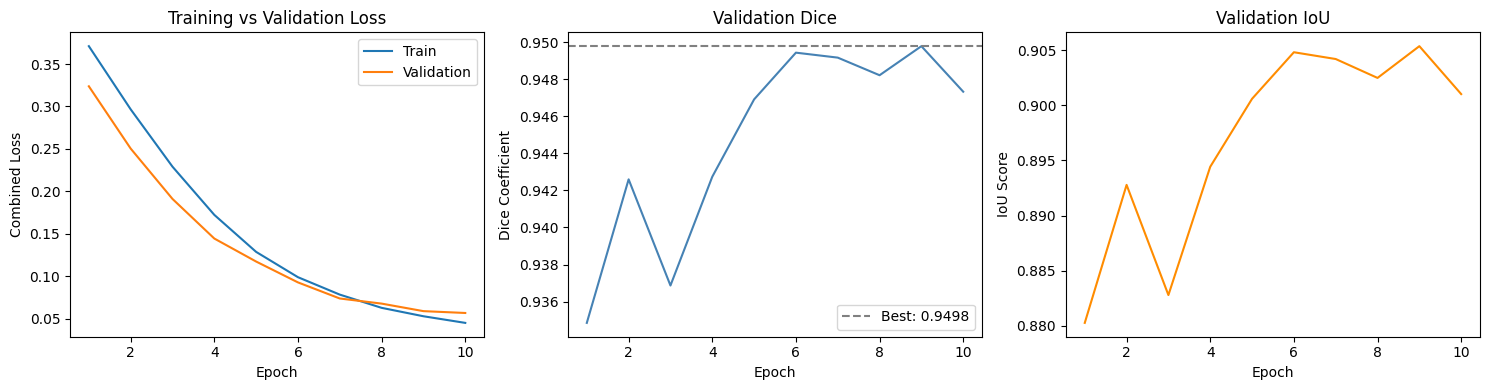

In [24]:

# SECTION 9 — TRAINING CURVES

epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Combined Loss')
axes[0].set_title('Training vs Validation Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['val_dice'], color='steelblue')
axes[1].axhline(y=best_dice, linestyle='--', color='gray',
                label=f'Best: {best_dice:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Coefficient')
axes[1].set_title('Validation Dice'); axes[1].legend()

axes[2].plot(epochs_range, history['val_iou'], color='darkorange')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU Score')
axes[2].set_title('Validation IoU')

plt.tight_layout()
plt.show()

In [25]:
# SECTION 10 — TEST SET EVALUATION

print("\nLoading best model for test evaluation...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

test_loss, test_dice, test_iou = validate(model, test_loader, criterion, device)

print("\n" + "="*45)
print("TEST SET RESULTS")
print("="*45)
print(f"  Loss : {test_loss:.4f}")
print(f"  Dice : {test_dice:.4f}")
print(f"  IoU  : {test_iou:.4f}")


Loading best model for test evaluation...



TEST SET RESULTS
  Loss : 0.0669
  Dice : 0.9409
  IoU  : 0.8920


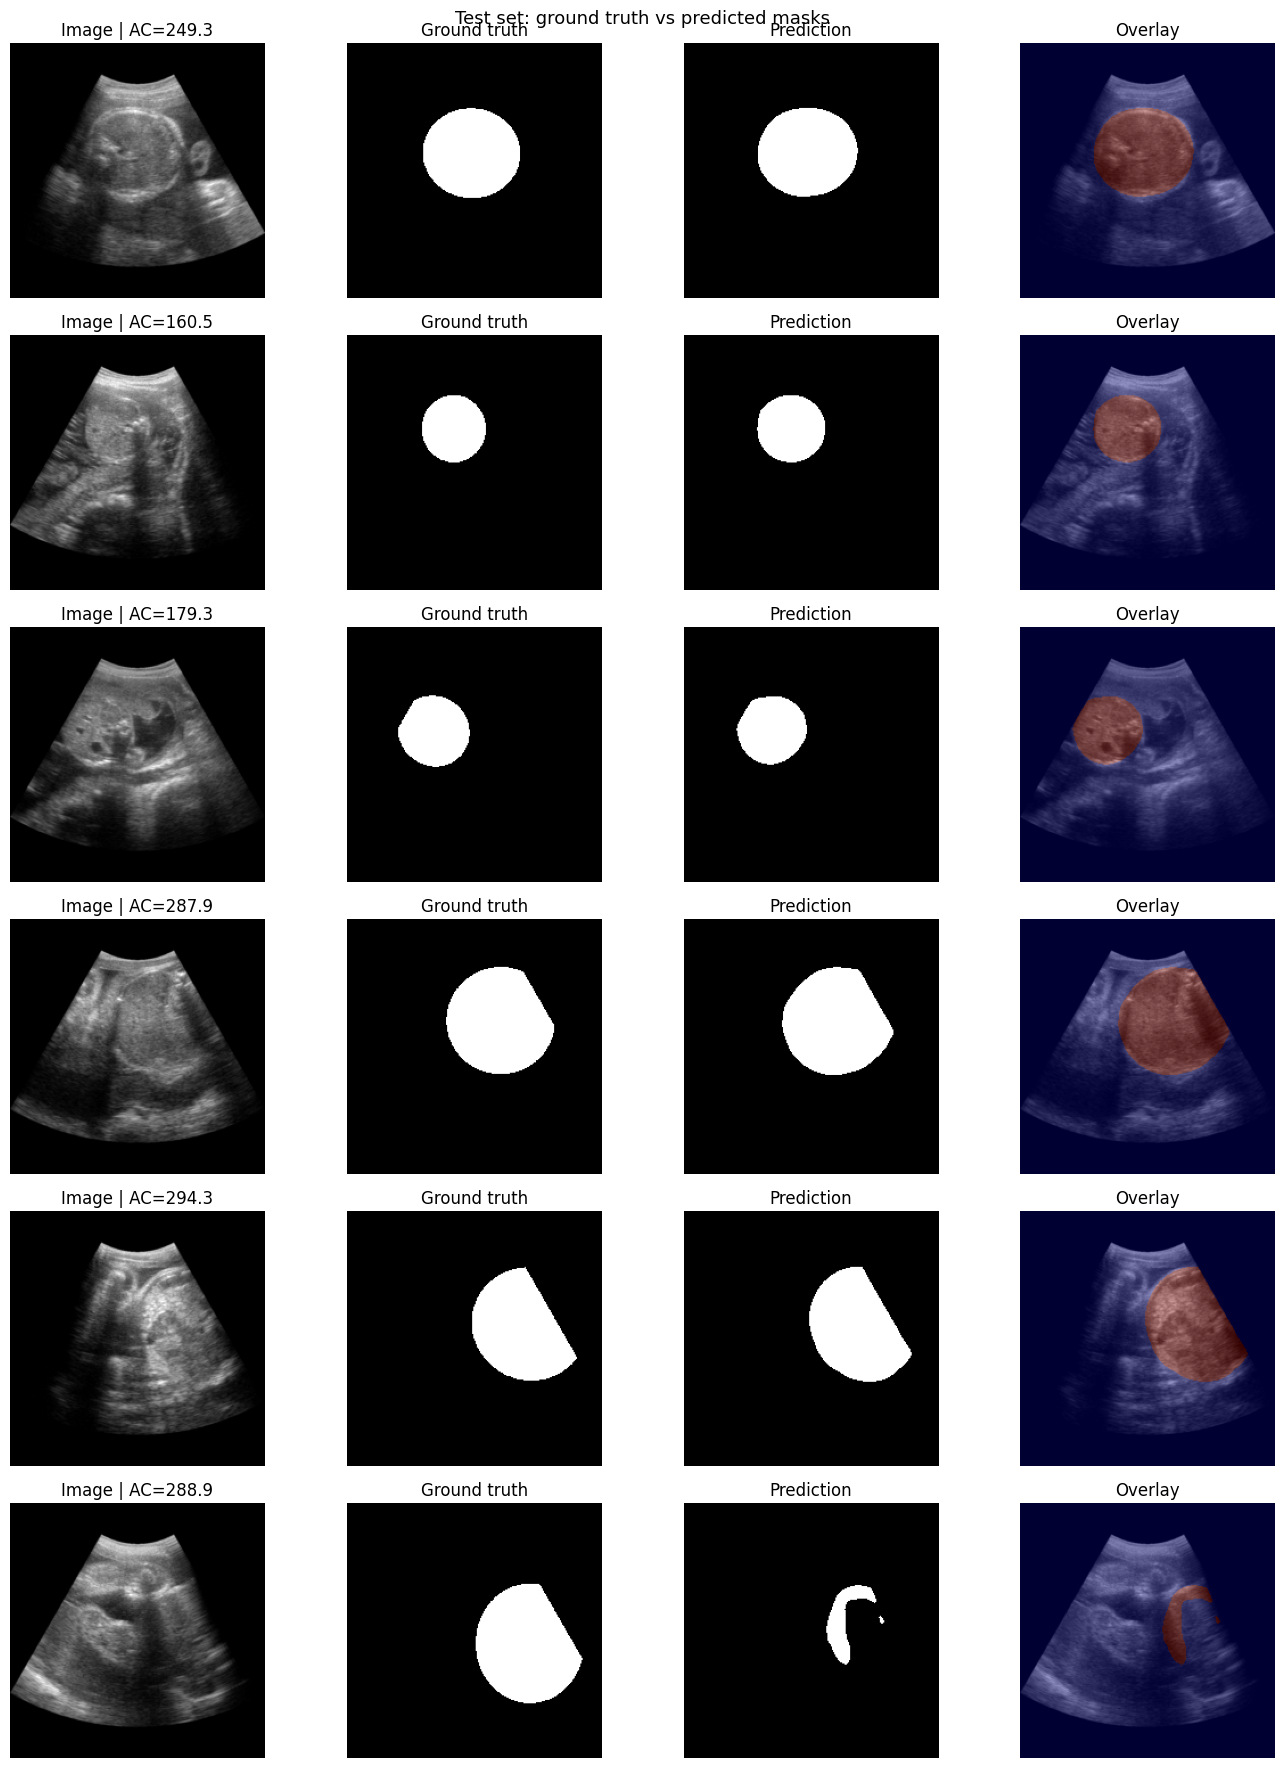

In [26]:
# SECTION 11 — QUALITATIVE VISUALISATION OF PREDICTIONS

def visualize_predictions(model, dataset, device, n=6, title="Predictions"):
    """
    4-column grid: image | ground truth | prediction | overlay
    """
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, n * 3))

    with torch.no_grad():
        for row_idx, sample_idx in enumerate(indices):
            img, mask_gt, ac = dataset[sample_idx]

            logit     = model(img.unsqueeze(0).to(device))
            prob      = torch.sigmoid(logit).squeeze().cpu().numpy()
            pred_mask = (prob > 0.5).astype(np.float32)

            img_display  = np.clip(img[0].numpy() * dataset.std + dataset.mean, 0, 1)
            mask_display = mask_gt[0].numpy()

            axes[row_idx, 0].imshow(img_display, cmap='gray')
            axes[row_idx, 0].set_title(f"Image | AC={ac:.1f}" if ac > 0 else "Image")
            axes[row_idx, 0].axis('off')

            axes[row_idx, 1].imshow(mask_display, cmap='gray')
            axes[row_idx, 1].set_title("Ground truth"); axes[row_idx, 1].axis('off')

            axes[row_idx, 2].imshow(pred_mask, cmap='gray')
            axes[row_idx, 2].set_title("Prediction"); axes[row_idx, 2].axis('off')

            axes[row_idx, 3].imshow(img_display, cmap='gray')
            axes[row_idx, 3].imshow(pred_mask, cmap='jet', alpha=0.4)
            axes[row_idx, 3].set_title("Overlay"); axes[row_idx, 3].axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, device, n=6,
                      title="Test set: ground truth vs predicted masks")

In [29]:
# SECTION 12 — ABDOMINAL CIRCUMFERENCE ESTIMATION
# =============================================================================
# Pipeline: predicted mask → contours → largest contour → fit ellipse
#           → Ramanujan perimeter formula → compare to ground-truth AC
# =============================================================================


ORIGINAL_SIZE    = 744            # max side of original image after PadToSquare
RESIZED_SIZE     = 224            # what we resized to
SCANNER_SPACING  = 0.28           # mm per pixel in the original scanner image

# Effective spacing in the resized 224×224 coordinate space
PIXEL_SPACING_MM = SCANNER_SPACING / (RESIZED_SIZE / ORIGINAL_SIZE)

print(f"Effective pixel spacing: {PIXEL_SPACING_MM:.4f} mm/pixel")
# Should print ~0.930


def fit_ellipse_and_compute_ac(binary_mask, pixel_spacing_mm=PIXEL_SPACING_MM):
    """
    Fit an ellipse to the largest contour in a binary mask and compute AC.

    Steps:
      1. Find all external contours in the binary mask
      2. Select the largest contour (most likely the abdomen boundary)
      3. Fit an ellipse using cv2.fitEllipse (requires >= 5 contour points)
      4. Convert semi-axes from pixels to mm using pixel_spacing_mm
      5. Apply Ramanujan's approximation: AC ≈ π[(a+b) + 3h/(10+√(4-3h))]
         where h = (a-b)² / (a+b)²

    Returns:
        ac_mm   : estimated circumference (mm or pixels if spacing=1.0)
        ellipse : cv2 ellipse tuple, or None on failure
        contour : the largest contour found, or None
    """
    mask_uint8  = (binary_mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None, None, None

    largest = max(contours, key=cv2.contourArea)

    if len(largest) < 5:
        return None, None, largest

    try:
        ellipse = cv2.fitEllipse(largest)
        a_px, b_px = ellipse[1][0] / 2.0, ellipse[1][1] / 2.0
        a_mm, b_mm = a_px * pixel_spacing_mm, b_px * pixel_spacing_mm

        # Ramanujan's approximation for ellipse perimeter
        h     = ((a_mm - b_mm) ** 2) / ((a_mm + b_mm) ** 2)
        ac_mm = np.pi * (a_mm + b_mm) * (1 + (3 * h) / (10 + np.sqrt(4 - 3 * h)))

        return ac_mm, ellipse, largest

    except cv2.error:
        return None, None, largest


def evaluate_ac_estimation(model, dataset, device, pixel_spacing_mm=PIXEL_SPACING_MM):
    """
    Run AC estimation over the full dataset and compare to ground-truth.
    Returns results list, MAE, and MAPE.
    """
    model.eval()
    results = []

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="  AC eval"):
            img, mask_gt, ac_true = dataset[idx]

            if ac_true.item() < 0:
                continue

            logit     = model(img.unsqueeze(0).to(device))
            prob      = torch.sigmoid(logit).squeeze().cpu().numpy()
            pred_mask = (prob > 0.5).astype(np.float32)

            ac_pred, _, _ = fit_ellipse_and_compute_ac(pred_mask, pixel_spacing_mm)

            if ac_pred is not None:
                results.append({
                    'ac_true'  : ac_true.item(),
                    'ac_pred'  : ac_pred,
                    'abs_error': abs(ac_pred - ac_true.item()),
                    'pct_error': abs(ac_pred - ac_true.item()) / (ac_true.item() + 1e-8) * 100,
                })

    if not results:
        print("No valid AC estimates. Check mask quality and AC column name.")
        return results, None, None

    mae     = np.mean([r['abs_error'] for r in results])
    mae_pct = np.mean([r['pct_error'] for r in results])

    print(f"\nAC Estimation — {len(results)} slices evaluated")
    print(f"  MAE  : {mae:.2f} {'mm' if pixel_spacing_mm != 1.0 else 'pixels'}")
    print(f"  MAPE : {mae_pct:.2f}%")

    return results, mae, mae_pct


print("\nEvaluating AC estimation on test set...")
ac_results, ac_mae, ac_mape = evaluate_ac_estimation(model, test_dataset, device)



Effective pixel spacing: 0.9300 mm/pixel

Evaluating AC estimation on test set...


  AC eval: 100%|██████████| 521/521 [00:12<00:00, 41.47it/s]


AC Estimation — 521 slices evaluated
  MAE  : 15.27 mm
  MAPE : 5.85%


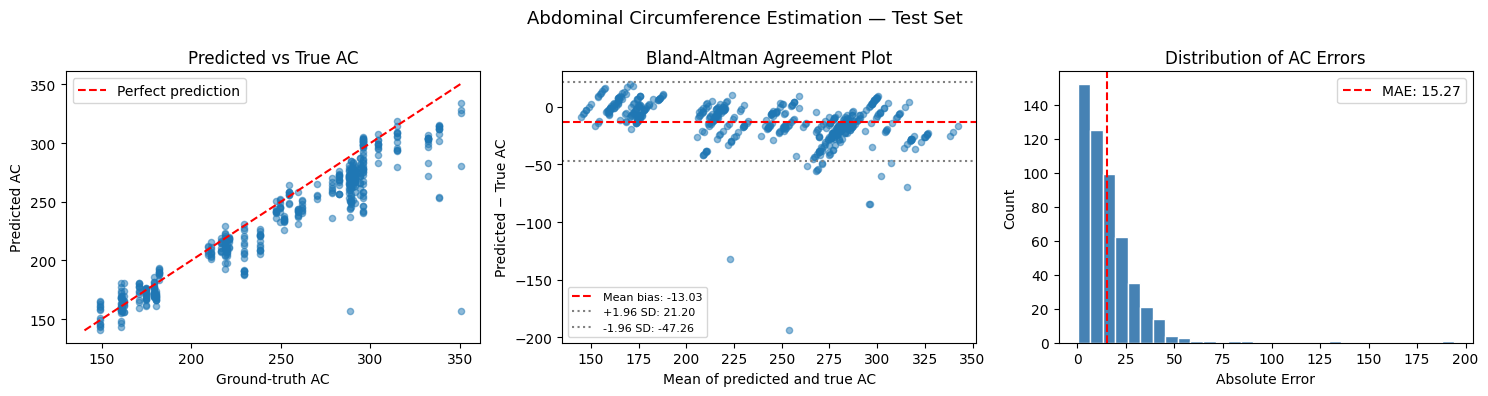


Bland-Altman: bias=-13.03, 95% LoA=[-47.26, 21.20]


In [30]:
# SECTION 13 — AC ERROR ANALYSIS PLOTS

if ac_results and len(ac_results) > 0:

    true_vals = [r['ac_true'] for r in ac_results]
    pred_vals = [r['ac_pred'] for r in ac_results]
    errors    = [r['abs_error'] for r in ac_results]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Scatter: predicted vs true
    axes[0].scatter(true_vals, pred_vals, alpha=0.5, s=20)
    mn, mx = min(min(true_vals), min(pred_vals)), max(max(true_vals), max(pred_vals))
    axes[0].plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
    axes[0].set_xlabel('Ground-truth AC'); axes[0].set_ylabel('Predicted AC')
    axes[0].set_title('Predicted vs True AC'); axes[0].legend()

    # Bland-Altman agreement plot
    means     = [(p + t) / 2 for p, t in zip(pred_vals, true_vals)]
    diffs     = [p - t       for p, t in zip(pred_vals, true_vals)]
    mean_diff = np.mean(diffs)
    std_diff  = np.std(diffs)

    axes[1].scatter(means, diffs, alpha=0.5, s=20)
    axes[1].axhline(mean_diff,
                    color='red',  linestyle='--',
                    label=f'Mean bias: {mean_diff:.2f}')
    axes[1].axhline(mean_diff + 1.96 * std_diff,
                    color='gray', linestyle=':',
                    label=f'+1.96 SD: {mean_diff + 1.96*std_diff:.2f}')
    axes[1].axhline(mean_diff - 1.96 * std_diff,
                    color='gray', linestyle=':',
                    label=f'-1.96 SD: {mean_diff - 1.96*std_diff:.2f}')
    axes[1].set_xlabel('Mean of predicted and true AC')
    axes[1].set_ylabel('Predicted − True AC')
    axes[1].set_title('Bland-Altman Agreement Plot')
    axes[1].legend(fontsize=8)

    # Error distribution
    axes[2].hist(errors, bins=30, color='steelblue', edgecolor='white')
    axes[2].axvline(ac_mae, color='red', linestyle='--',
                    label=f'MAE: {ac_mae:.2f}')
    axes[2].set_xlabel('Absolute Error'); axes[2].set_ylabel('Count')
    axes[2].set_title('Distribution of AC Errors'); axes[2].legend()

    plt.suptitle('Abdominal Circumference Estimation — Test Set', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\nBland-Altman: bias={mean_diff:.2f}, "
          f"95% LoA=[{mean_diff-1.96*std_diff:.2f}, {mean_diff+1.96*std_diff:.2f}]")


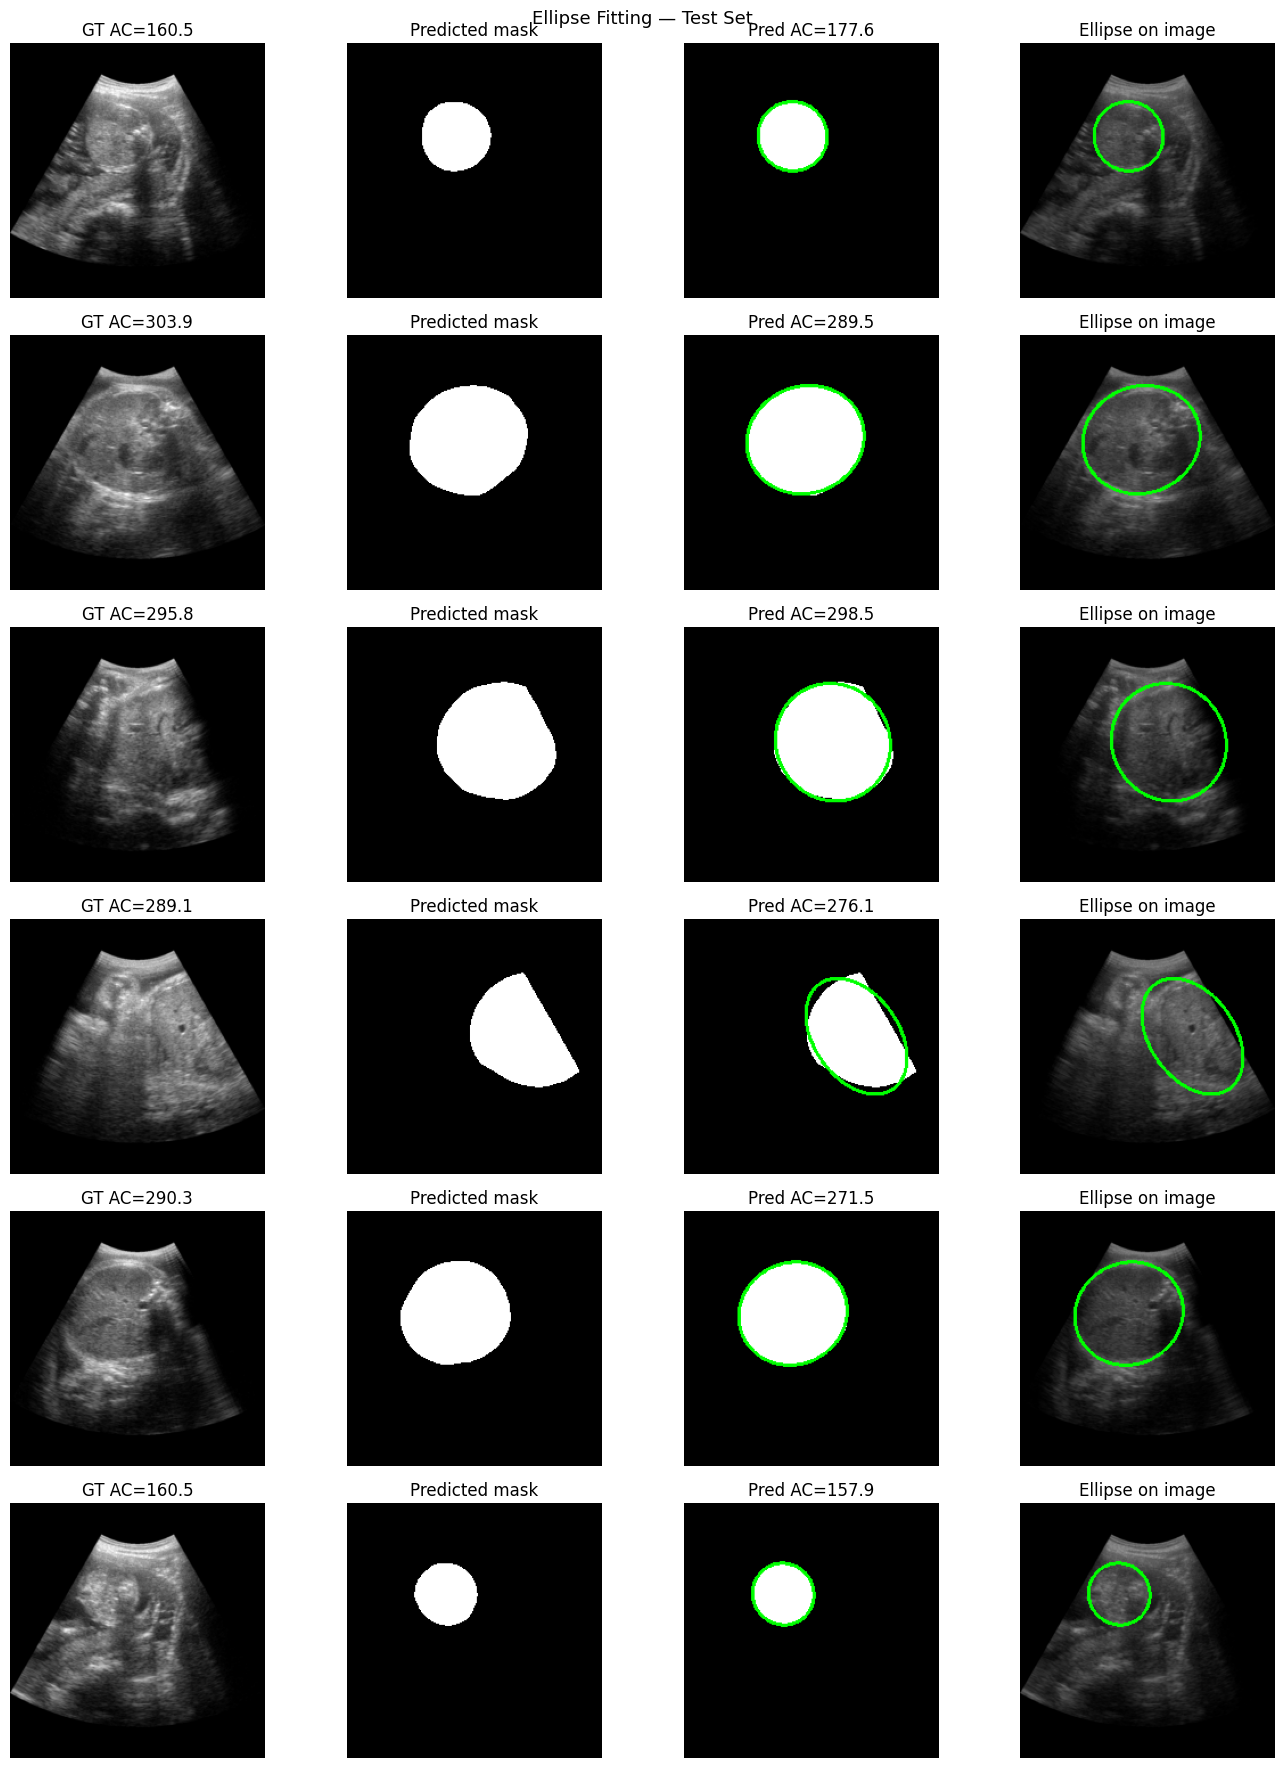

In [31]:
# SECTION 14 — VISUALISING ELLIPSE FITTING


def visualize_ellipse_fitting(model, dataset, device, n=6):
    """
    4-column grid: image | predicted mask | mask + ellipse | image + ellipse
    """
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, n * 3))

    with torch.no_grad():
        for row_idx, sample_idx in enumerate(indices):
            img, mask_gt, ac_true = dataset[sample_idx]

            logit     = model(img.unsqueeze(0).to(device))
            prob      = torch.sigmoid(logit).squeeze().cpu().numpy()
            pred_mask = (prob > 0.5).astype(np.float32)

            ac_pred, ellipse, _ = fit_ellipse_and_compute_ac(pred_mask)

            img_display = np.clip(img[0].numpy() * dataset.std + dataset.mean, 0, 1)

            # Draw ellipse on mask and image using OpenCV
            mask_bgr = cv2.cvtColor((pred_mask * 255).astype(np.uint8),
                                    cv2.COLOR_GRAY2BGR)
            img_bgr  = cv2.cvtColor((img_display * 255).astype(np.uint8),
                                    cv2.COLOR_GRAY2BGR)

            if ellipse is not None:
                cv2.ellipse(mask_bgr, ellipse, (0, 255, 0), 2)
                cv2.ellipse(img_bgr,  ellipse, (0, 255, 0), 2)

            axes[row_idx, 0].imshow(img_display, cmap='gray')
            axes[row_idx, 0].set_title(f"GT AC={ac_true:.1f}" if ac_true > 0 else "Image")
            axes[row_idx, 0].axis('off')

            axes[row_idx, 1].imshow(pred_mask, cmap='gray')
            axes[row_idx, 1].set_title("Predicted mask"); axes[row_idx, 1].axis('off')

            axes[row_idx, 2].imshow(mask_bgr)
            axes[row_idx, 2].set_title(f"Pred AC={ac_pred:.1f}" if ac_pred else "No ellipse")
            axes[row_idx, 2].axis('off')

            axes[row_idx, 3].imshow(img_bgr)
            axes[row_idx, 3].set_title("Ellipse on image"); axes[row_idx, 3].axis('off')

    plt.suptitle("Ellipse Fitting — Test Set", fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_ellipse_fitting(model, test_dataset, device, n=6)


In [32]:
#final summary
print("STAGE 2 COMPLETE — SUMMARY")
print("="*50)
print(f"  Model saved to  : {MODEL_SAVE_PATH}")
print(f"  Test Dice       : {test_dice:.4f}")
print(f"  Test IoU        : {test_iou:.4f}")
if ac_mae:
    print(f"  AC MAE          : {ac_mae:.2f}")
    print(f"  AC MAPE         : {ac_mape:.2f}%")
print()
print("Next steps:")
print("  Step B — Unified architecture (shared ResNet-34 encoder)")
print("  Step C — Direct AC regression")
print("  Step D — End-to-end inference pipeline")
print("  Step E — Gradio demo UI")

STAGE 2 COMPLETE — SUMMARY
  Model saved to  : /content/drive/MyDrive/best_seg_model.pth
  Test Dice       : 0.9409
  Test IoU        : 0.8920
  AC MAE          : 15.27
  AC MAPE         : 5.85%

Next steps:
  Step B — Unified architecture (shared ResNet-34 encoder)
  Step C — Direct AC regression
  Step D — End-to-end inference pipeline
  Step E — Gradio demo UI
